In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from math import ceil, sqrt
import copy
import scipy.stats

## Black & Scholes model

In [54]:
class MultiDimensionalBS:
    def __init__(self, initial_prices, interest_rate, dividends, volatilities, correlation_matrix):
        self.initial_prices = initial_prices
        self.interest_rate = interest_rate
        self.dividends = dividends
        self.volatilities = volatilities
        self.correlation_matrix = correlation_matrix
        self.dimension = len(initial_prices)
        self.var_cov = np.linalg.cholesky(np.matmul(np.diag(self.volatilities), np.matmul(self.correlation_matrix, np.diag(self.volatilities))))
        
        assert self.dimension == len(self.dividends) and self.dimension == len(self.volatilities) and self.dimension == len(self.var_cov[0]) and self.dimension == len(self.var_cov), "Arrays should have same lenght as the problem dimension !"
    
    def Simulate(self, expiry, nb_time_discr, number_paths):
        """ Simulate stock prices under BS model until expiry and with constant timestep """
        diffusion_list = np.linspace(0, expiry, nb_time_discr + 1)
        last_index = len(diffusion_list) - 1
        delta_time = expiry / last_index
        dW = np.sqrt(delta_time) * np.random.randn(number_paths, last_index, self.dimension)
        dW = np.append(np.zeros((number_paths, 1, self.dimension)), dW, axis=1)
        cst = self.interest_rate - self.dividends - 0.5 * (self.volatilities ** 2)
        W = np.cumsum(np.matmul(dW, self.var_cov), axis = 1)
        S = self.initial_prices * np.exp(cst * diffusion_list[np.newaxis, :, np.newaxis] + W)
                    
        return S
    
    def Simulate_Next_State(self, current_price, current_time, diffusion_times, nb_paths):
        """ Simulate conditionnal stock prices under BS model until expiry and with constant timestep """
        delta_time = diffusion_times[0] - current_time
        dW = np.sqrt(delta_time) * np.random.randn(nb_paths, len(diffusion_times), self.dimension)
        cst = self.interest_rate - self.dividends - 0.5 * (self.volatilities ** 2)
        W = np.cumsum(np.matmul(dW, self.var_cov), axis = 1)
        S = current_price[:, np.newaxis, np.newaxis, :] * np.exp(cst * (diffusion_times[np.newaxis, :, np.newaxis] - current_time) + W)
                    
        return S

## Payoffs Management

In [55]:
class Payoff:
    def __init__(self, strike, option_type):
        self.strike = strike
        self.option_type = option_type
        
    def value(self, asset_prices, interest_rate, dates, k=0):
        if (self.option_type == 0):
            # max call
            return np.exp(-interest_rate * dates[np.newaxis, k:]) * np.maximum(asset_prices.max(axis = 2) - self.strike, 0)
        
        elif (self.option_type == 1):
            # max put
            return np.exp(-interest_rate * dates[np.newaxis, k:]) * np.maximum(self.strike - asset_prices.min(axis = 2), 0)
        
        elif (self.option_type == 2):
            d = len(asset_prices[0][0])
            # geometric call
            np.exp(-interest_rate * dates[np.newaxis, k:]) * np.maximum(asset_prices.prod(axis = 2)**(1/d) - self.strike, 0)

## Neural Net Training

In [56]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [57]:
def Build_Neural_Network(nn_structure):
    
    nb_hidden_layers = len(nn_structure) - 2
    assert nb_hidden_layers >= 2, " A neural network has a least two layers : input and output "
    
    layers = []
        
    for i in range(0, nb_hidden_layers):
        layers += [nn.Linear(nn_structure[i], nn_structure[i + 1]), nn.BatchNorm1d(nn_structure[i + 1]), nn.ReLU()]
      
    layers += [torch.nn.Linear(nn_structure[nb_hidden_layers], nn_structure[nb_hidden_layers + 1]), torch.nn.Sigmoid()]
    
    return nn.Sequential(*layers)

In [58]:
def model_train(nn_structure, nn_hyper_params, model_params, nb_epoch_before_display, payoff_obj,re_use_nn_params = False):
    
    # nn_structure : list containing specification of hidden layer : 
    # nn_hyper_params : dict containing nn hyperparameters
    # model_params : dict containing BS model parameters
    # re_use_nn_params : if True : we previously trained nn to initialize current nn weights

    #################################################################################################################
    ####################################################                  MODELS INIT
    
    N = len(model_params['diffusion_times']) - 1
    nb_batches = ceil(nn_hyper_params['inputs_size'] / nn_hyper_params['batch_size'])
    
    nn_base = Build_Neural_Network(nn_structure)
    f = [copy.deepcopy(nn_base).to(device) for i in range(N - 1)]
    optimizers = [torch.optim.Adam(f[i].parameters(), lr = nn_hyper_params['lr']) for i in range(N - 1)]
    BS = MultiDimensionalBS(model_params['initial_prices'], model_params['interest_rate'], model_params['dividends'], model_params['volatilities'], model_params['correlation_matrix'])
    losses = np.array([[0.0] * (N - 1)] * (nn_hyper_params['nb_epochs'] // nb_epoch_before_display))
    
    comp = 0
    
    #################################################################################################################
    ####################################################                  TRAINING

    for epoch in range(nn_hyper_params['nb_epochs']):
        S_train = BS.Simulate(model_params['diffusion_times'][-1], N, nn_hyper_params['inputs_size'])
        x = torch.from_numpy(S_train).float()
        y = torch.unsqueeze(torch.from_numpy(payoff_obj.value(S_train, model_params['interest_rate'], model_params['diffusion_times'])), dim=2).float()
        payoff_tau = [y[i * nn_hyper_params['batch_size'] : min((i + 1) * nn_hyper_params['batch_size'], nn_hyper_params['inputs_size']) , N].to(device) for i in range(nb_batches)]
        this_epoch_loss = np.full(N - 1, 0.0)
        
        # bakward induction
        
        for n in range(N - 1, 0, -1):
            inputs = torch.cat((x[:,n], y[:,n]), 1)
            
            if n < N - 2 and re_use_nn_params:
                f[n].parameters = f[n + 1].parameters
            
            for batch in range(nb_batches):
                batch_range = [i for i in range(batch * nn_hyper_params['batch_size'], min((batch + 1) * nn_hyper_params['batch_size'], nn_hyper_params['inputs_size']))]
                this_batch_inputs = inputs[batch_range, :].to(device)
                optimizers[n - 1].zero_grad()
                F_n = f[n - 1](this_batch_inputs)
                f_n = (F_n >= 0.5).detach().float()
                payoffs_batch = y[batch_range , n].to(device)
                payoff_tau[batch] = payoffs_batch * f_n + payoff_tau[batch] * (1 - f_n)
                z = torch.mean(torch.mul(torch.subtract(payoff_tau[batch], payoffs_batch), F_n))
                this_epoch_loss[n - 1] += z.item() / float(nb_batches)
                z.backward()
                optimizers[n - 1].step()
                
        '''if(epoch % nb_epoch_before_display == 0):
            losses[comp] = this_epoch_loss 
            print('epoch {}, losses : {}'.format(epoch, losses[comp]))
            print('\n')
            comp += 1'''
                
    return f, losses

## Test

In [59]:
dimensions = [1,5,10,100]
expiry = 3
nb_ex_dates = 9
strike = 100
my_payoff = Payoff(strike, 0)

K_L = 1096000
J = 16384
K_U = 1024

In [60]:
def get_model(dim,plot_loss = True):

    dimension = dim

    # NN parameters
    nn_units = [dimension + 1] + [dimension + 40 for _ in range(2)] + [1]
    nb_epoch_before_display = 100
    nn_hp = {'lr' : 0.001, 'nb_epochs' : 3000, 'batch_size' : 8192, 'inputs_size' : 8192*1}

    BS_params = {'initial_prices' : np.full(dimension, 100),
                'interest_rate' : 0.05,
                'dividends' : np.full(dimension, 0.1),
                'volatilities' : np.full(dimension, 0.2),
                'diffusion_times' : np.linspace(0, expiry, nb_ex_dates + 1),
                'correlation_matrix' : np.eye(dimension)}

    my_models, losses= model_train(nn_units, nn_hp, BS_params,nb_epoch_before_display,my_payoff)
    if plot_loss:
        epoch = np.array([i * nb_epoch_before_display for i in range(nn_hp['nb_epochs'] // nb_epoch_before_display)])
        plt.figure(figsize=(15,8))
        for i in range(len(losses[0])):
            plt.plot(epoch, losses[:,i])
        plt.xlabel("epoch")
        plt.ylabel("loss")
    return my_models, losses

# # Lower Bound

In [61]:
def get_lower_bound(BS_params,my_models):
    BS_lower = MultiDimensionalBS(BS_params['initial_prices'], BS_params['interest_rate'], BS_params['dividends'], BS_params['volatilities'], BS_params['correlation_matrix'])
    S_lower = BS_lower.Simulate(expiry, nb_ex_dates, K_L)
    x = torch.from_numpy(S_lower).float()
    y = torch.unsqueeze(torch.from_numpy(my_payoff.value(S_lower, BS_params['interest_rate'], BS_params['diffusion_times'])), dim=2).float()
    
    # init
    tau = y[:,nb_ex_dates].new_full(y[:,nb_ex_dates].shape, nb_ex_dates).to(device)
    payoff_tau = y[:,nb_ex_dates].to(device)

    # backward induction
    for n in range(nb_ex_dates - 1, 0, -1):
        inputs = torch.cat((x[:,n], y[:,n]), 1)
        f_n = (my_models[n - 1](inputs.to(device)) >= 0.5).detach().float()
        tau = n * f_n + tau * (1 - f_n)
        payoffs = y[:, n].to(device)
        payoff_tau = payoffs * f_n + payoff_tau * (1 - f_n)
        #print(n, 'reward :', payoff_tau.mean())
        
    # initial date
    payoffs = y[:,0].to(device)
    f_n = (payoffs >= (payoff_tau).mean()).detach().float()
    tau *= (1 - f_n)
    payoff_tau = payoffs * f_n + payoff_tau * (1 - f_n)

    lower = payoff_tau
    return lower,lower.mean().item()

# # Upper Bound

In [62]:
def get_upper_bound(BS_params, my_models):
    
    BS_upper = MultiDimensionalBS(BS_params['initial_prices'], BS_params['interest_rate'],
                                  BS_params['dividends'], BS_params['volatilities'], BS_params['correlation_matrix'])
    S_upper = BS_upper.Simulate(expiry, nb_ex_dates, K_U)

    x = torch.from_numpy(S_upper).float()
    y = torch.unsqueeze(torch.from_numpy(my_payoff.value(
        S_upper, BS_params['interest_rate'], BS_params['diffusion_times'])), dim=2).float()

    S_cond = BS_upper.Simulate_Next_State(
        S_upper[:, nb_ex_dates - 1, :], BS_params['diffusion_times'][nb_ex_dates - 1], BS_params['diffusion_times'][nb_ex_dates:], J)
    y_cond = [my_payoff.value(S_cond[k], BS_params['interest_rate'],
                              BS_params['diffusion_times'][nb_ex_dates:]) for k in range(K_U)]
    C_n_1 = torch.from_numpy(np.mean(np.squeeze(
        [y_cond[k] for k in range(K_U)], axis=2), axis=1)).to(device)
    mg_increments = torch.from_numpy(
        np.array([[0.0] * K_U] * (nb_ex_dates + 1)))
    mg_increments[nb_ex_dates] = y[:, nb_ex_dates, 0].to(device) - C_n_1
    f_n = [[torch.from_numpy(np.array([[1.0] * 1] * J)).to(device)] * 1] * K_U

    for n in range(nb_ex_dates - 1, 0, -1):
        S_cond = BS_upper.Simulate_Next_State(
            S_upper[:, n - 1, :], BS_params['diffusion_times'][n - 1], BS_params['diffusion_times'][n:], J)
        y_cond = [torch.unsqueeze(torch.from_numpy(my_payoff.value(
            S_cond[k], BS_params['interest_rate'], BS_params['diffusion_times'][n:])), dim=2).float() for k in range(K_U)]
        S_cond = torch.from_numpy(S_cond).float()

        inputs = [[torch.cat((S_cond[k][:, m], y_cond[k][:, m]), 1)
                   for m in range(0, nb_ex_dates - n)] for k in range(K_U)]
        payoff_tau = [y_cond[k][:, nb_ex_dates -
                                n].to(device) for k in range(K_U)]

        if (not (n == nb_ex_dates - 1)):
            f_n = [[(my_models[n + m - 1](inputs[k][m].to(device)) >= 0.5).detach().float()
                    for m in range(0, nb_ex_dates - n)] for k in range(K_U)]

            for m in range(nb_ex_dates - n - 1, -1, -1):
                payoff_tau = [y_cond[k][:, m, :].to(
                    device) * f_n[k][m] + (1 - f_n[k][m]) * payoff_tau[k] for k in range(K_U)]

        C_n = C_n_1
        C_n_1 = [torch.mean(torch.squeeze(payoff_tau[k], dim=1)).item()
                 for k in range(K_U)]
        C_n_1 = torch.from_numpy(np.array(C_n_1)).to(device)

        inputs = torch.cat((x[:, n], y[:, n]), 1)
        f_n = (my_models[n - 1](inputs.to(device)) >= 0.5).detach().float()
        mg_increments[n] = (y[:, n, 0].to(device) - C_n) * \
            torch.squeeze(f_n, dim=1) + C_n - C_n_1

    mg_doob = torch.cumsum(torch.transpose(mg_increments, 0, 1), dim=1)

    upper = (y[:, :, 0].to(device) - mg_doob.to(device)).max(dim=1).values
    return upper,upper.mean().item()
    

In [63]:
def get_interval(dim,BS_params,CI = 0.95):
    my_models, _ = get_model(dim,plot_loss = True)
    z = scipy.stats.norm.ppf(0.5+CI/2) 
    
    lower, lower_bound = get_lower_bound(BS_params, my_models)
    upper, upper_bound = get_upper_bound(BS_params, my_models)
    IC_inf = round(lower_bound - z * torch.std(lower).item() / sqrt(K_L), 3)
    IC_sup = round(upper_bound + z * torch.std(upper).item() / sqrt(K_U), 3)

    print('- lower bound :', round(lower_bound, 3))
    print('- upper bound :', round(upper_bound, 3))
    print('- point estimator :', round((lower_bound + upper_bound) / 2.0, 3))
    print('')
    print('IC 95% :', (IC_inf, IC_sup))

- lower bound : 7.96
- upper bound : 8.183
- point estimator : 8.072

IC 95% : (7.938, 8.215)


KeyboardInterrupt: 

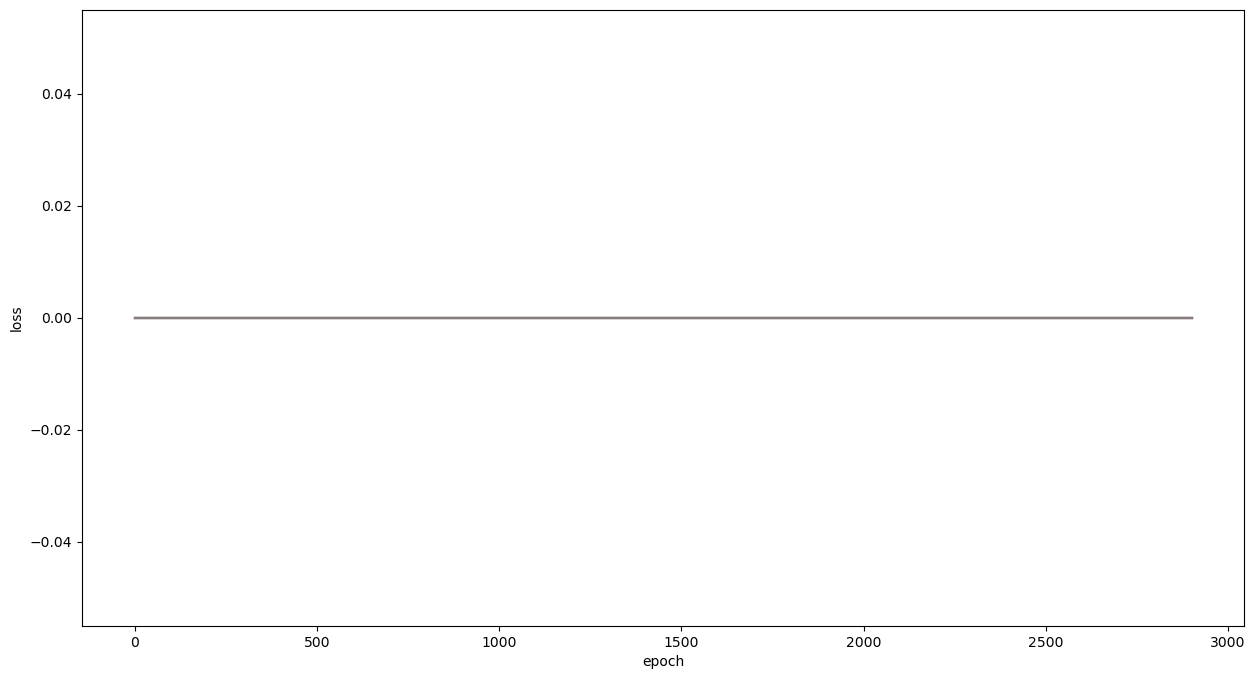

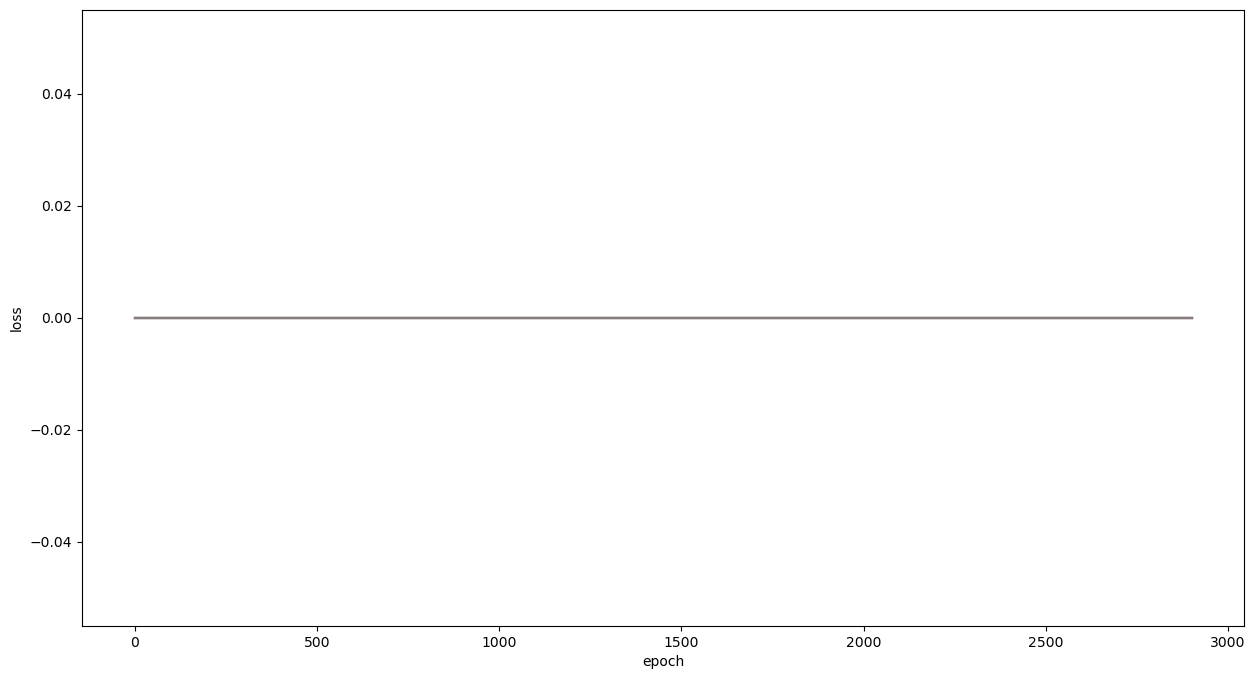

In [64]:
for dim in dimensions:
    BS_params = {'initial_prices' : np.full(dim, 100),
                'interest_rate' : 0.05,
                'dividends' : np.full(dim, 0.1),
                'volatilities' : np.full(dim, 0.2),
                'diffusion_times' : np.linspace(0, expiry, nb_ex_dates + 1),
                'correlation_matrix' : np.eye(dim)}
    get_interval(dim,BS_params,CI = 0.95)

In [ ]:
# to do : qq tests et graphes

##### 